# Project 2: The Two-Dimensional Ising Model

The 2D Ising model on a square lattice of $N = L \times L$ sites is defined by the Hamiltonian:

$$\mathcal{H} = -J \sum_{\langle i,j \rangle} \sigma_i \sigma_j$$

where $\sigma_i = \pm 1$ represents an Ising spin at site $i$, and $J > 0$ is the ferromagnetic coupling between nearest neighbors $\langle i,j \rangle$. We will use periodic boundary conditions.

This simple model is the "fruit fly" of statistical physics. At low temperature, energy wins and the spins align; at high temperature, entropy wins and they point randomly. In 1944 Onsager solved the model exactly and showed that on the infinite lattice ($N \rightarrow \infty$) the competition is settled by a genuine **phase transition** at a temperature $T_c$ between a disordered state at high temperature and a magnetic state with a finite magnetization $\langle m \rangle \ne 0$, where

\begin{equation}
  \langle m \rangle = \lim_{N \rightarrow \infty}
     \frac{1}{N} \sum_{i=1}^N \langle \sigma_i \rangle
\end{equation}

The value of the critical temperature (we set $k_B=1$) is

\begin{equation}
  \frac{T_c}{J} = \frac{2}{\log (1 + \sqrt{2})} \simeq 2.269
\end{equation}

and the magnetization and energy are known exactly too:

\begin{equation}
  \langle m \rangle = \begin{cases} \big(1 - \sinh^{-4}(2J/T)\big)^{1/8}, & T < T_c \\ 0, & T > T_c \end{cases}
\end{equation}

\begin{equation}
  \langle e \rangle = -J \coth(2J/T) \left[ 1 + \frac{2}{\pi} \big(2\tanh^2(2J/T) - 1\big) \mathrm{K}(k) \right]
\end{equation}

where $k = \frac{2\sinh(2K)}{\cosh^2(2K)}$ and $\mathrm{K}(k)$ is the complete elliptic integral of the first kind.

The goal of this project is to study the two-dimensional Ising model with a Monte Carlo algorithm, and to see whether we can find evidence for the phase transition even though we will only ever be dealing with finite systems (where, strictly speaking, there is no phase transition at all!).

In [61]:
# Common imports
%matplotlib inline
import numpy as np
from scipy.special import ellipk

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import ListedColormap
from matplotlib.image import AxesImage
from IPython.display import HTML

# the random number generator
rng = np.random.default_rng(seed=2026)

# to draw a spin configuration
SPIN_CMAP = ListedColormap(["#f0efec", "#0072b2"])
def show_spins(spins: np.ndarray, ax: plt.Axes | None = None) -> AxesImage:
    """Draw a spin configuration (down = light, up = blue) and return the image artist."""
    ax = ax if ax is not None else plt.gca()
    im = ax.imshow(spins, cmap=SPIN_CMAP, vmin=-1, vmax=1, interpolation="nearest")
    ax.set(xticks=[], yticks=[])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
    return im

# the critical temperature
T_C = 2 / np.log(1 + np.sqrt(2))  # Onsager's critical temperature (J = 1)

# the formula for the energy
def onsager_energy(T: np.ndarray | float, J: float = 1.0) -> np.ndarray:
    """Energy per spin of the infinite lattice."""
    K = J / np.asarray(T, dtype=float)
    k = 2 * np.sinh(2 * K) / np.cosh(2 * K) ** 2
    return -J / np.tanh(2 * K) * (1 + 2 / np.pi * (2 * np.tanh(2 * K) ** 2 - 1) * ellipk(k**2))

# the formula for the magnetization
def onsager_magnetization(T: np.ndarray | float, J: float = 1.0) -> np.ndarray:
    """Spontaneous magnetization per spin of the infinite lattice (Yang)."""
    T = np.asarray(T, dtype=float)
    below = T < 2 * J / np.log(1 + np.sqrt(2))
    x = np.sinh(2 * J / np.where(below, T, 1.0)) ** -4
    return np.where(below, np.clip(1 - x, 0, None) ** 0.125, 0.0)

## Warmup: Compute $\pi$ by Monte Carlo

In order to get familiar with the generation of random numbers, you can try to write a
Monte Carlo algorithm to compute $\pi$. The idea, as we saw in the lecture, is to start
from a circle of radius 1, inside a square box of length 2. You then throw randomly
(uniformly) stones in the square box. After having thrown many stones you can compute
the fraction of those that landed inside the circle. This will give you an estimate
for $\pi$.

Random numbers in modern numpy are drawn from a *generator* object:

```python
rng = np.random.default_rng(seed=42)   # the seed makes the run reproducible
rng.uniform(-1, 1, size=(10, 2))       # 10 random points in the square [-1, 1]^2
```

*Challenge*: Show that the error bar on the value of $\pi$ goes like $1 / \sqrt{M}$, where
$M$ is the number of stones. To do this, you will need to make several runs (about 100) for
the same fixed $M$ and compute the standard deviation of the estimates.

slope = -0.488  (expected -0.5)
b = 0.421 with 10^b = 1.523. 


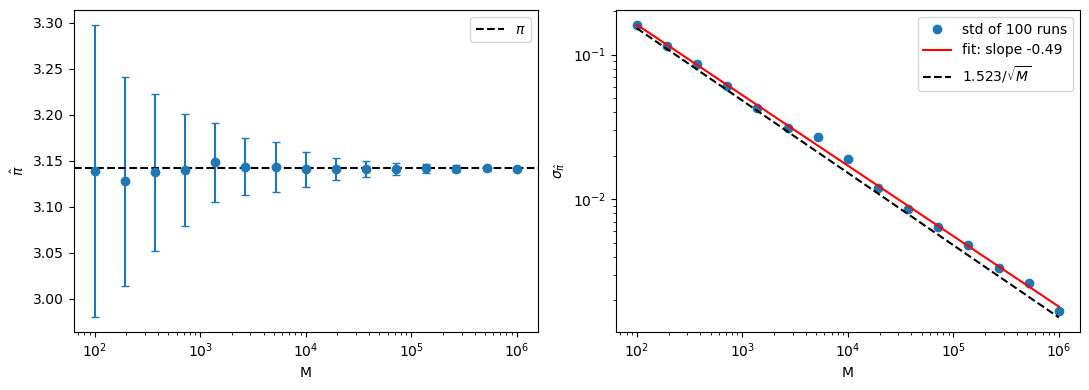

In [62]:
rng = np.random.default_rng(seed=42)

def estimate_pi(limits, M, rng):
    # limits: array with the limits on x,y axis. Assumes limits for x and y are equal
    # M: number of generated points
    # rng: random numer generator, initialised previously

    pts = rng.uniform(limits[0],limits[1],size=(M,2))
    x, y = pts[:,0], pts[:,1]

    inside = x**2 + y**2 <= 1 #array of Trues
    M_in = inside.sum()

    return 4*(M_in/M)


def err_pi_vs_M(limits, Ms, n_runs, rng):
    # Ms: array of M values (integers)
    # n_runs: number of independent runs for each M (~100)

    mean_pi, std_pi = [], []

    for M in Ms:
        runs = np.array([estimate_pi(limits, M, rng) for _ in range(n_runs)])
        mean_pi.append(runs.mean())
        std_pi.append(runs.std(ddof=1))   # error bar = std of the estimates

    return np.array(mean_pi), np.array(std_pi)


limits = [-1, 1]
Ms = np.logspace(2, 6, 15).astype(int)   # from 10^2 to 10^6 stones
mean_pi, std_pi = err_pi_vs_M(limits, Ms, 100, rng)

#---------------------- PLOT WITH FIT -----------------------------------------------

# fit of the slope in log-log: log(err) = a*log(M) + b
a, b = np.polyfit(np.log(Ms), np.log(std_pi), 1)
beta=np.e**b
print(f"slope = {a:.3f}  (expected -0.5)")
print(f"b = {b:.3f} with 10^b = {beta:.3f}. ")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# left: estimate of pi with error bars
ax1.errorbar(Ms, mean_pi, yerr=std_pi, fmt='o', capsize=3)
ax1.axhline(np.pi, color='k', ls='--', label=r'$\pi$')
ax1.set(xscale='log', xlabel='M', ylabel=r'$\hat\pi$')
ax1.legend()

# right: error vs M in log-log
ax2.loglog(Ms, std_pi, 'o', label='std of 100 runs')
ax2.loglog(Ms, np.exp(b) * Ms**a, 'r-', label=f'fit: slope {a:.2f}')
ax2.loglog(Ms, beta / np.sqrt(Ms), 'k--', label=r'$1.523/\sqrt{M}$')
ax2.set(xlabel='M', ylabel=r'$\sigma_{\hat\pi}$')
ax2.legend()

plt.tight_layout()
plt.show()



## Part 1: Set up a class for the Ising model

Let's first start and write a class that will describe the Ising model. The class
should have a constructor taking $T$, $J$, $L$ and a random number generator as parameters. It generates
a random initial state which can be encoded in an $L\times L$
`numpy.ndarray` of $\pm 1$. We use periodic boundary conditions. The class could have a structure like

```python
class Configuration:
    def __init__(self, T: float, J: float, L: int, rng: np.random.Generator) -> None:
        self.size = L
        self.spins = ...
        ...

    def get_energy(self) -> float:
        ...

    def get_magnetization(self) -> int:
        ...
```

In order to test your class, you can instantiate it and plot the spin configuration
using the `show_spins` function defined above. You can also check your class methods by generating
special configurations with all spins up or a checkerboard (Néel) pattern and see whether the energy
and magnetization are those you expect.

*Hint*: `np.roll(spins, -1, axis=1)` shifts the array by one site, with periodic
boundary conditions. It gives you all the right neighbors at once, without any loop.

In [63]:
class Configuration:
    def __init__(self,T,J,L,rng):
        self.size = L
        self.temp = T
        self.coupling_const = J
        self.rng = rng
        self.spins = rng.choice([-1,1],size=(L,L))
        self.energy = self.get_energy()
        self.magnetization = self.get_magnetization()

    def get_energy(self):
        s = self.spins
        right = np.roll(s,-1,axis=1) # right[i, j] = s[i, j+1]
        down = np.roll(s, -1, axis=0) # down[i, j] = s[i+1, j]
        sumation = np.sum(s*right + s*down)

        return -self.coupling_const*sumation

    def get_magnetization(self):
        return np.sum(self.spins)

40 -2


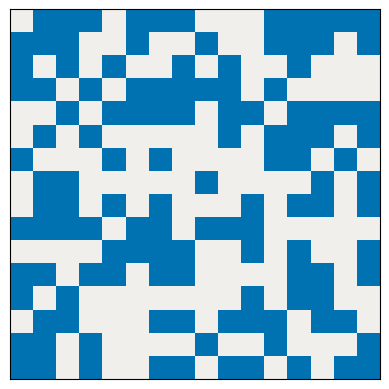

In [64]:
config = Configuration(T=2,J=1,L=16,rng=rng)
E=config.get_energy()
m=config.get_magnetization()
print(E, m)
show_spins(spins=config.spins,ax=None)

## Part 2: The Metropolis move

Here you will write a function that performs a Metropolis Monte Carlo
move on the configuration. The function takes an Ising configuration
(an instance of the `Configuration` class) as an argument and has
the following signature:

```python
def metropolis_move(config: Configuration) -> None:
    ...
```

The function should choose a random site, compute the energy difference
between the old configuration and the new configuration where the spin
has been flipped and decide whether the move should be accepted or
not (using the Metropolis algorithm). Warning: in order to compute the
energy difference, only consider the energy change from the links involving
the flipped spin. Indeed, all the other links are unchanged and it would
be a waste of time to recompute the full energy every time.

How to check? Start from a small lattice, say $4 \times 4$, and call
`metropolis_move` many times at a rather high temperature. This way,
you should sample many different configurations. If your energy calculation
is right, the energy per spin should always be between $-2J$ and $2J$, and the energy
you update after each move should always agree with the one recomputed from scratch.

In [65]:
def metropolis_move(config):

    L = config.size
    s = config.spins

    i,j = config.rng.integers(0, L, size=2) # chooses a random point from the lattice
    #s_ij_move = -1 * spins[i,j] #change the sign of the spin

    delta_E = (s[(i + 1) % L, j] + s[(i - 1) % L, j] + s[i, (j + 1) % L] + s[i, (j - 1) % L]) #sums on nn of i
    delta_E = delta_E * (2 * config.coupling_const * s[i,j])

    A = min(1, np.exp(-delta_E / config.temp))
    if config.rng.random() < A:
        s[i,j] *= -1
        config.energy += delta_E
        config.magnetization += 2 * s[i, j]



In [66]:
config = Configuration(T=10.0, J=1.0, L=4, rng=rng)   # T alta, red 4x4
N = config.size**2

n_steps = 10000
E_upd, E_scratch = np.zeros(n_steps), np.zeros(n_steps)

for t in range(n_steps):
    metropolis_move(config) # this call modifies the config parameters!!! 
    E_upd[t] = config.energy
    E_scratch[t] = config.get_energy()

print("¿Do they match always?", np.allclose(E_upd, E_scratch))
print("Maximum difference:", np.max(np.abs(E_upd - E_scratch)))
print("(E/spin)_min, (E/spin)_max:", E_upd.min() / N, E_upd.max() / N)   # deben estar en [-2, 2]


¿Do they match always? True
Maximum difference: 0.0
(E/spin)_min, (E/spin)_max: -2.0 1.25


## Part 3: The Monte Carlo simulation live!

Write an animation that shows the evolution of the spins. In order for the animation not to be
too slow, the function that is repeatedly called by `FuncAnimation` should make many spin
flip trials (typically $L\times L$, which we call a *sweep*). Otherwise the animation will be
really slow. You might want to get more details about
[`matplotlib.animation.FuncAnimation`](https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.FuncAnimation.html)
on the matplotlib website. In a notebook, the simplest way to display the animation is

```python
from IPython.display import HTML

ani = animation.FuncAnimation(fig, update, frames=200, interval=40)
plt.close(fig)            # do not show the static figure as well
HTML(ani.to_jshtml())     # an interactive player with play / pause / speed controls
```

and you can save it to a file with `ani.save("ising.mp4")` or `ani.save("ising.gif")`.

See how the system behaves for different:

- Temperatures
- System sizes

In [67]:
from IPython.display import HTML

class Animation:
    def __init__(self, config, n_frames, sweeps_per_frame):
        self.config_anim = config
        self.n_frames = n_frames
        self.sweeps_per_frame = sweeps_per_frame

    def sweep(self):
        # L*L metropolis moves = 1 sweep
        for _ in range(self.config_anim.size**2):
            metropolis_move(self.config_anim)

    def init(self):
        # called once by FuncAnimation before the first frame (without it, update(0) would run twice)
        return self.im, self.title, self.line_m

    def update(self, frame):
        # called by FuncAnimation at every frame
        for _ in range(self.sweeps_per_frame):
            self.sweep()
        N = self.config_anim.size**2
        m = self.config_anim.magnetization / N

        # left: spins
        self.im.set_data(self.config_anim.spins)
        self.title.set_text(f"T = {self.config_anim.temp},  "
                            f"sweep {(frame + 1) * self.sweeps_per_frame}\n"
                            f"m = {m:+.2f}")

        # right: m vs sweeps (history of all the frames so far)
        self.sweeps_hist.append((frame + 1) * self.sweeps_per_frame)
        self.m_hist.append(m)
        self.line_m.set_data(self.sweeps_hist, self.m_hist)

        return self.im, self.title, self.line_m

    def run(self):
        fig, (ax, ax_m) = plt.subplots(1, 2, figsize=(10, 4.5))

        # left: spins
        self.im = show_spins(self.config_anim.spins, ax=ax)
        # placeholder text so tight_layout reserves space for a 2-line title
        self.title = ax.set_title("T = 0,  sweep 0\nm = +0.00", fontsize=11)

        # right: magnetization per spin
        N = self.config_anim.size**2
        self.sweeps_hist = [0]
        self.m_hist = [self.config_anim.magnetization / N]
        self.line_m, = ax_m.plot(self.sweeps_hist, self.m_hist, color="#0072b2")
        ax_m.axhline(0, color="k", ls="--", lw=1)          # line at m = 0
        ax_m.set(xlim=(0, self.n_frames * self.sweeps_per_frame), ylim=(-1.05, 1.05),
                 xlabel="sweeps", ylabel="m = M/N")

        plt.tight_layout()
        ani = animation.FuncAnimation(fig, self.update, frames=self.n_frames,
                                      init_func=self.init, interval=40)
        plt.close(fig)
        return HTML(ani.to_jshtml())


config_anim = Configuration(T=10.0, J=1.0, L=32, rng=rng)
Animation(config_anim, n_frames=200, sweeps_per_frame=1).run()


## Part 4: Compute physical averages

The animation above allows to get some insight into the physics of the
model. But it is necessary to compute some physical averages to understand
more. Because two configurations that only differ by a spin flip are very
correlated, one usually waits a certain number of steps before considering
a new configuration in the computation of an average. In practice, the
Monte Carlo simulation can be cut into cycles: a cycle is a certain number
of steps needed to decorrelate the configurations. Also, in the beginning of
the simulation, one needs to wait for the Markov chain to reach its stationary
distribution. These variables can be used:

- `length_cycle`: the number of steps between two *measurements*, i.e. between two
   configurations that are used to compute physical averages.

- `n_cycles`: the number of cycles used to compute the averages. This number
   corresponds to the number of measurements.

- `n_warmup`: the number of cycles that are performed in the beginning of the
   simulation without any measurement. They are done so that the Markov
   chain reaches a stationary distribution.

You can now write a Monte Carlo simulation:

1. Compute the average magnetization $m$ as a function of the number of
  Monte Carlo steps on a $20 \times 20$ lattice. This will allow you to
  judge how many steps are necessary to reach equilibrium. How
  does this change with temperature and system size?

2. You can then more systematically compute the magnetization, the energy, the
  magnetic susceptibility and specific heat as a function of the temperature.
  Start with a rather small lattice $4 \times 4$ and then increase the size.
  How do these quantities vary? Recall that

  \begin{equation}
    c = \frac{\langle E^2 \rangle - \langle E \rangle^2}{N T^2}
    \qquad
    \chi = \frac{\langle M^2 \rangle - \langle M \rangle^2}{N T}
  \end{equation}

  where $E$ and $M$ are the total energy and magnetization.

You will see that these simulations can take some time. Rather than
plotting directly after the simulation is done, you might want to save
your averages into files and in another cell read the information from these
files to do the plots. It is very common to organize a numerical work like
this: a production part that generates the data and a postprocessing part
to do the plots etc. To save and read numpy arrays you can use:

```python
np.savez("results_L4.npz", temperature=temperatures, energy=energy)
data = np.load("results_L4.npz")
data["energy"]
```

## Part 5: Autocorrelation time

Above we said that configurations that differ only by a spin flip are very correlated
and that a certain number of moves are needed to make two configurations
independent. As a rule of thumb, we used $L\times L$ updates to disentangle
configurations.

However, as we will see here, as one gets closer to the phase transition, it becomes
harder and harder to decorrelate two configurations. A way to measure this in
the disordered state is to compute the *autocorrelation time* through the quantity

\begin{equation}
  \mathcal{C}(t) = \langle m(t) \, m(0) \rangle - \langle m \rangle^2
\end{equation}

where $m(t)$ is the magnetization of the system at (Monte Carlo) time $t$.
If two configurations are completely decorrelated $\mathcal{C}(t)$ should
be zero. Usually $\mathcal{C}(t) \sim \exp(-t / \tau)$ where $\tau$ is the
autocorrelation time.

Write a code that computes the autocorrelation time at a given temperature
and study it as the temperature is reduced closer to the critical
temperature. You can start with an $8 \times 8$ lattice.